In [178]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
from scipy import interpolate


##### To Do:

- make butterworth filter accordingly
- fix sheet for a good analysis of the force and put it in lists so it can easily be compared
- put the forces on percentage of stance time and then interpolate! 

##### Already done:

- Butterworth filter adjusted and good -> also good for Amelie?
- interpolating yhe vertical GRF

In [179]:
import scipy.io as sio

data = sio.loadmat("../files/Straight/25_Straight_2.mat", squeeze_me=True, struct_as_record=False)

qtm = data["qtm_25_Straight_2"]

FP1 = qtm.Force[0]
FP2 = qtm.Force[1]

Fx1 = -(FP1.Force[0])
Fy1 = -(FP1.Force[1])
Fz1 = -(FP1.Force[2])

Fx2 = -(FP2.Force[0])
Fy2 = -(FP2.Force[1])
Fz2 = -(FP2.Force[2])

x1 = np.arange(len(Fx1))
x2 = np.arange(len(Fx2))


In [180]:
def butter_lowpass_filter(
    data: list[float], cutoff: float = 100 , fs: float = 1000, order: int = 4) -> list[float]:
    """Pas een Butterworth low-pass filter toe en retourneer het gefilterde signaal.

    De functie gebruikt second-order sections (SOS) en `sosfiltfilt` voor
    zero-phase filtering (geen faseverschuiving).

    Args:
        data: 1D-iterable met numerieke waarden (list of numpy array).
        cutoff: afkapfrequentie in Hz.
        fs: samplefrequentie in Hz.
        order: filterorde (typisch 2-8).

    Returns:
        Numpy-array met de gefilterde waarden (zelfde lengte als input).
    """
    data = np.asarray(data)
    if data.size == 0:
        return data
    nyq = 0.5 * fs
    wn = float(cutoff) / nyq
    sos = butter(order, wn, btype='low', output='sos')
    return sosfiltfilt(sos, data)

In [181]:
def dual_butterworth(data, cutoff=100, fs=1000):
    data = butter_lowpass_filter(data, cutoff=cutoff, fs=fs, order=2)
    data = butter_lowpass_filter(data, cutoff=cutoff, fs=fs, order=2)
    return data

-8.304157764027412
-8.314356863747953


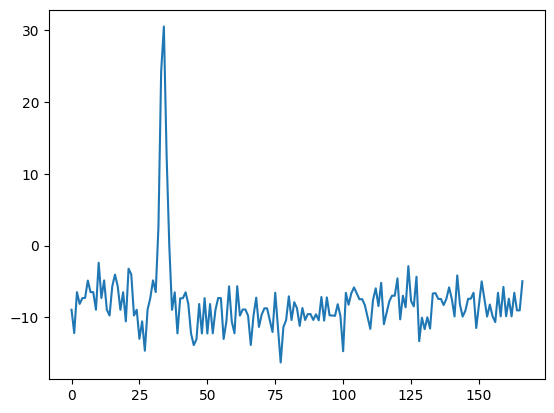

In [182]:
# Take the offset of the force plate
# Fx, Fy, Fz of FP1
correction = np.median(Fz1[Fz1 < 50])
plt.plot(Fz1[Fz1 < 50])
correction2 = np.mean(Fz1[150:])
print(correction)
print(correction2)
Fx1 = Fx1 - correction
Fy1 = Fy1 - correction
Fz1 = Fz1 - correction

Fx2 = Fx2 - correction
Fy2 = Fy2 - correction
Fz2 = Fz2 - correction

In [183]:
Fz1 = butter_lowpass_filter(Fz1, cutoff= 120, fs= 1000, order= 4)
Fz1[Fz1 < 31] = 0

Fz2 = butter_lowpass_filter(Fz2, cutoff= 120, fs= 1000, order= 4)
Fz2[Fz2 < 31] = 0


In [184]:
IC1 = [i for i in range(1, len(Fz1)) if Fz1[i] != 0 and (Fz1[i-1] == 0)][0]
TO1 = [i for i in range(0, len(Fz1)) if Fz1[i] == 0 and (Fz1[i-1] != 0)][0]

IC2 = [i for i in range(1, len(Fz2)) if Fz2[i] != 0 and (Fz2[i-1] == 0)][0]
TO2 = [i for i in range(0, len(Fz2)) if Fz2[i] == 0 and (Fz2[i-1] != 0)][0]

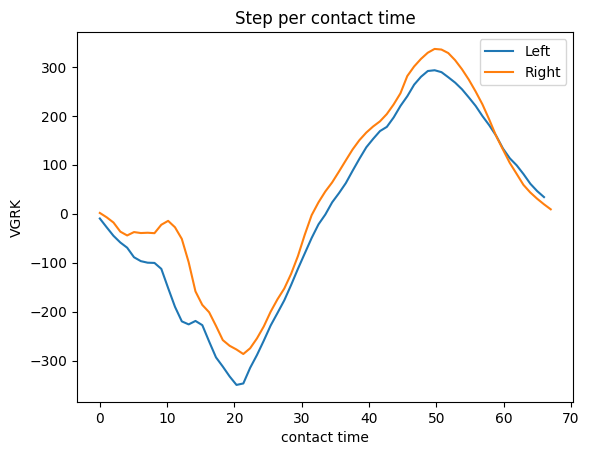

In [185]:
segments = []
contacttijden = []

segment1 = Fy1[IC1:TO1]
segment2 = Fy2[IC2:TO2]

segments.append(segment1)
segments.append(segment2)

contacttijden.append(TO1 - IC1)
contacttijden.append(TO2 - IC2)

for ct, seg in zip(contacttijden, segments): #Belangrijk: zip stopt wanneer de kortste lijst op is. Als contacttijd en segments verschillende lengtes hebben, worden overtollige items genegeerd zonder foutmelding. Dat kan stilletjes verkeerde resultaten geven — controleer gelijkheid van lengtes met len().
            seg = np.array(seg)
            # lokale tijd-as 0 → ct
            t = np.linspace(0, ct, len(seg))
        # np.linspace(start, stop, num) maakt num gelijkmatig verdeelde punten tussen start en stop inclusief beide eindpunten.
        # Hier: we maken een lokale tijdas t die van 0 naar ct gaat met precies len(seg) punten. Daardoor heeft elk datapunt in seg een corresponderende x-waarde.
        # Gevolg: elk segment wordt horizontaal geschaald zodat het begint op 0 en eindigt op ct (dus x-eenheden zijn dezelfde als ct).
            plt.plot(t, seg) # Tekent één curve: x-waarden t tegen y-waarden seg. => Omdat je dit binnen de for-lus doet, worden alle segmenten in hetzelfde figuur over elkaar heen geplot

plt.plot()
plt.xlabel("contact time")
plt.ylabel("VGRK")
plt.title("Step per contact time")
plt.legend(["Left","Right"])
plt.show()

##### Interpolate


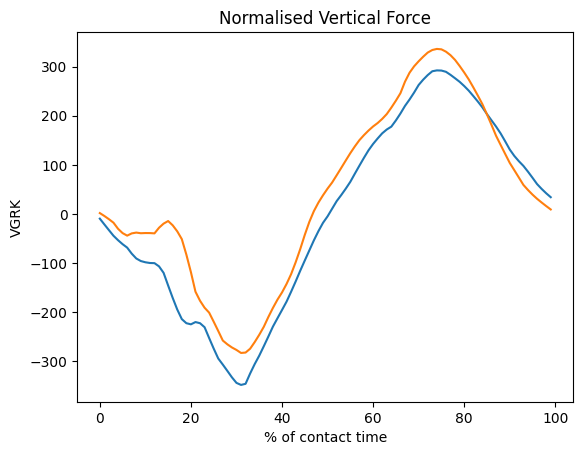

In [186]:
norm_segm = []
for segment in segments:
    if len(segment) > 1:
        x_orig = np.linspace(0, 1, len(segment))
        x_new = np.linspace(0, 1, 100)
        f = interpolate.interp1d(x_orig, segment)
        normalized_segment = f(x_new)
        norm_segm.append(normalized_segment)

plt.figure()
plt.plot(norm_segm[0])
plt.plot(norm_segm[1])
plt.xlabel("% of contact time")
plt.ylabel("VGRK")
plt.title("Normalised Vertical Force")
plt.show()

In [187]:
def GRF_stat(force="Fz",force_plate="FP1", stat = "mean"):

    func = getattr(np, stat)

    if force == "Fz":
        return func(Fz1), func(Fz2)
    elif force == "Fx":
        return func(Fx1), func(Fx2)
    else:
        return func(Fy1), func(Fy2)

In [188]:
Fz_max_L, Fz_max_R = GRF_stat("Fy", stat= "max")
print(Fz_max_L, Fz_max_R)

293.1522955675256 336.7181646352603
